In [1]:
# 1. Imports & Global Settings

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Project paths (assumes notebook is in /notebooks)
BASE_DIR = Path("..").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
REPORTS_FIG = BASE_DIR / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
REPORTS_FIG.mkdir(parents=True, exist_ok=True)

print("Paths initialized:")
print("RAW:", DATA_RAW)
print("PROCESSED:", DATA_PROCESSED)
print("FIGURES:", REPORTS_FIG)


Paths initialized:
RAW: C:\Users\jsrin\post_discharge_strategy\data\raw
PROCESSED: C:\Users\jsrin\post_discharge_strategy\data\processed
FIGURES: C:\Users\jsrin\post_discharge_strategy\reports\figures


In [2]:
# 2. Load Raw HRRP Dataset


file_path = DATA_RAW / "cms_hrrp_hospital_readmissions_raw.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape (rows, cols):", df.shape)

display(df.head())


Dataset loaded successfully.
Shape (rows, cols): (18510, 12)


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,296.0000,NaN,0.9483,13.0146,13.7235,36,07/01/2020,06/30/2023
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,151.0000,NaN,0.9509,9.6899,10.1898,13,07/01/2020,06/30/2023
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HF-HRRP,681.0000,NaN,1.0597,21.5645,20.3495,151,07/01/2020,06/30/2023
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9654,4.2680,4.4211,Too Few to Report,07/01/2020,06/30/2023
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,490.0000,NaN,0.9715,16.1137,16.5863,77,07/01/2020,06/30/2023


In [3]:
# 3. Quick Schema Scan


print("Columns:", len(df.columns))
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.values}).head(30))

print("\nMissingness (top 20):")
display(df.isna().mean().sort_values(ascending=False).head(20))

print("\nSample unique values check (top columns):")
for col in df.columns[:10]:
    print(f"{col}: {df[col].nunique()} unique")


Columns: 12


,column,dtype
0,Facility Name,object
1,Facility ID,int64
2,State,object
3,Measure Name,object
4,Number of Discharges,float64
5,Footnote,float64
6,Excess Readmission Ratio,float64
7,Predicted Readmission Rate,float64
8,Expected Readmission Rate,float64
9,Number of Readmissions,object



Missingness (top 20):


Footnote                     0.6444
Number of Discharges         0.5494
Excess Readmission Ratio     0.3556
Predicted Readmission Rate   0.3556
Expected Readmission Rate    0.3556
Number of Readmissions       0.3556
Facility Name                0.0000
Facility ID                  0.0000
State                        0.0000
Measure Name                 0.0000
Start Date                   0.0000
End Date                     0.0000
dtype: float64


Sample unique values check (top columns):
Facility Name: 3021 unique
Facility ID: 3085 unique
State: 51 unique
Measure Name: 6 unique
Number of Discharges: 1029 unique
Footnote: 3 unique
Excess Readmission Ratio: 3272 unique
Predicted Readmission Rate: 11466 unique
Expected Readmission Rate: 11394 unique
Number of Readmissions: 285 unique


In [4]:
# 4. Basic Cleaning

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

display(df.columns)


Index(['facility_name', 'facility_id', 'state', 'measure_name',
       'number_of_discharges', 'footnote', 'excess_readmission_ratio',
       'predicted_readmission_rate', 'expected_readmission_rate',
       'number_of_readmissions', 'start_date', 'end_date'],
      dtype='object')

In [5]:
# 5. Convert Numeric Columns Properly


numeric_cols = [
    "number_of_discharges",
    "excess_readmission_ratio",
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "number_of_readmissions"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion complete.")
df[numeric_cols].dtypes


Numeric conversion complete.


number_of_discharges          float64
excess_readmission_ratio      float64
predicted_readmission_rate    float64
expected_readmission_rate     float64
number_of_readmissions        float64
dtype: object

In [6]:
# 6. Filter Modeling Population


initial_rows = df.shape[0]

df_model = df[df["excess_readmission_ratio"].notna()].copy()

final_rows = df_model.shape[0]

print(f"Initial rows: {initial_rows}")
print(f"Rows after removing missing ERR: {final_rows}")
print(f"Removed: {initial_rows - final_rows}")


Initial rows: 18510
Rows after removing missing ERR: 11927
Removed: 6583


In [7]:
# 7. Measure Distribution


measure_counts = df_model["measure_name"].value_counts()

display(measure_counts)

print("\nPercentage by measure:")
display((measure_counts / measure_counts.sum()).round(3))


measure_name
READM-30-PN-HRRP          2731
READM-30-HF-HRRP          2638
READM-30-COPD-HRRP        2324
READM-30-AMI-HRRP         1763
READM-30-HIP-KNEE-HRRP    1588
READM-30-CABG-HRRP         883
Name: count, dtype: int64


Percentage by measure:


measure_name
READM-30-PN-HRRP         0.2290
READM-30-HF-HRRP         0.2210
READM-30-COPD-HRRP       0.1950
READM-30-AMI-HRRP        0.1480
READM-30-HIP-KNEE-HRRP   0.1330
READM-30-CABG-HRRP       0.0740
Name: count, dtype: float64

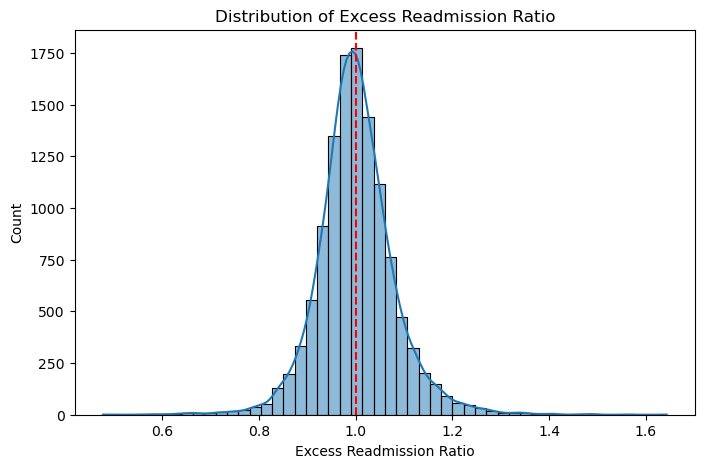

Mean ERR: 1.0017194935859812
Median ERR: 0.9982
Std ERR: 0.08054703085101969


In [8]:
# 8. Excess Readmission Ratio Distribution


plt.figure(figsize=(8,5))
sns.histplot(df_model["excess_readmission_ratio"], bins=50, kde=True)
plt.axvline(1.0, color="red", linestyle="--")
plt.title("Distribution of Excess Readmission Ratio")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Count")

plt.savefig(REPORTS_FIG / "err_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mean ERR:", df_model["excess_readmission_ratio"].mean())
print("Median ERR:", df_model["excess_readmission_ratio"].median())
print("Std ERR:", df_model["excess_readmission_ratio"].std())


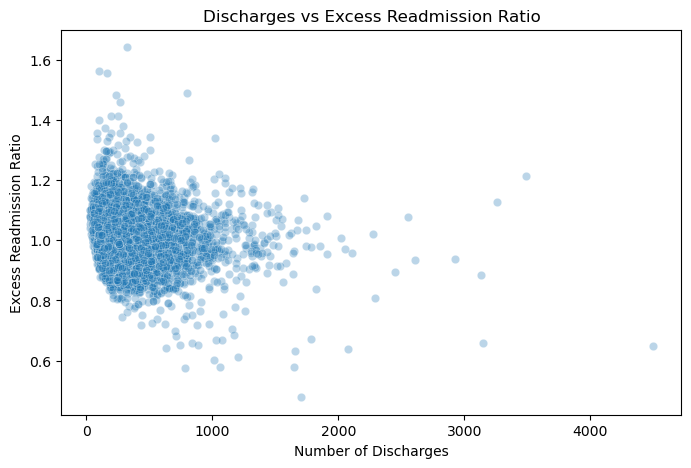

In [9]:
# ==========================================
# 9. Volume vs ERR Analysis
# ==========================================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model,
    x="number_of_discharges",
    y="excess_readmission_ratio",
    alpha=0.3
)

plt.title("Discharges vs Excess Readmission Ratio")
plt.xlabel("Number of Discharges")
plt.ylabel("Excess Readmission Ratio")

plt.savefig(REPORTS_FIG / "volume_vs_err.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# ==========================================
# 10. Z-Score Within Measure
# ==========================================

df_model["err_z_within_measure"] = (
    df_model.groupby("measure_name")["excess_readmission_ratio"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

print("Z-score feature created.")
df_model[["measure_name", "excess_readmission_ratio", "err_z_within_measure"]].head()


Z-score feature created.


,measure_name,excess_readmission_ratio,err_z_within_measure
0,READM-30-AMI-HRRP,0.9483,-0.7520
1,READM-30-CABG-HRRP,0.9509,-0.6210
2,READM-30-HF-HRRP,1.0597,0.8765
3,READM-30-HIP-KNEE-HRRP,0.9654,-0.2665
4,READM-30-PN-HRRP,0.9715,-0.4605


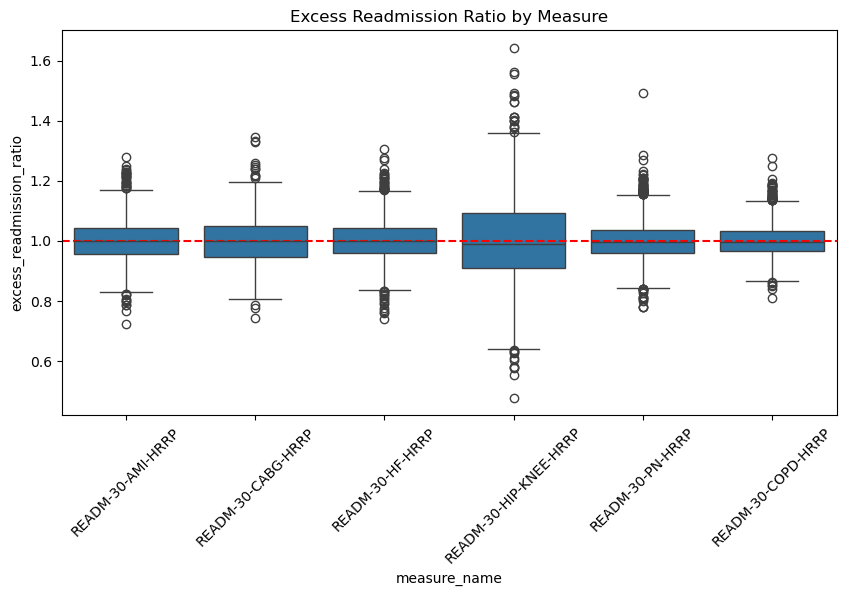

In [11]:
# 11. ERR by Measure


plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_model,
    x="measure_name",
    y="excess_readmission_ratio"
)

plt.axhline(1.0, color="red", linestyle="--")
plt.xticks(rotation=45)
plt.title("Excess Readmission Ratio by Measure")

plt.savefig(REPORTS_FIG / "err_by_measure.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
# 12. Reporting Period Structure


print("Unique Start Dates:", df_model["start_date"].nunique())
print("Unique End Dates:", df_model["end_date"].nunique())

display(df_model[["start_date", "end_date"]].drop_duplicates().sort_values("start_date"))


Unique Start Dates: 1
Unique End Dates: 1


,start_date,end_date
0,07/01/2020,06/30/2023


In [13]:
# 13. Hospital-Level Aggregate Risk


hospital_summary = (
    df_model
    .groupby("facility_id")
    .agg(
        facility_name=("facility_name", "first"),
        state=("state", "first"),
        avg_err=("excess_readmission_ratio", "mean"),
        avg_err_z=("err_z_within_measure", "mean"),
        err_std=("excess_readmission_ratio", "std"),
        total_discharges=("number_of_discharges", "sum"),
        measure_count=("measure_name", "count")
    )
    .reset_index()
)

hospital_summary.head()


,facility_id,facility_name,state,avg_err,avg_err_z,err_std,total_discharges,measure_count
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,AL,0.9715,-0.4169,0.0453,1748.0000,6
1,10005,MARSHALL MEDICAL CENTERS,AL,0.8906,-1.4982,0.0693,625.0000,4
2,10006,NORTH ALABAMA MEDICAL CENTER,AL,0.9926,-0.1639,0.0498,1689.0000,6
3,10007,MIZELL MEMORIAL HOSPITAL,AL,1.0284,0.4935,0.0425,120.0000,4
4,10011,ST. VINCENT'S EAST,AL,1.0252,0.3859,0.0601,915.0000,6


In [14]:
hospital_summary.shape


(2862, 8)

In [15]:
# 14. Volume-Weighted ERR


# Merge discharge and ERR back at hospital-measure level
df_model["weighted_err_component"] = (
    df_model["excess_readmission_ratio"] * df_model["number_of_discharges"]
)

hospital_weighted = (
    df_model
    .groupby("facility_id")
    .agg(
        total_weighted_err=("weighted_err_component", "sum"),
        total_discharges=("number_of_discharges", "sum")
    )
)

hospital_weighted["volume_weighted_err"] = (
    hospital_weighted["total_weighted_err"] /
    hospital_weighted["total_discharges"]
)

hospital_weighted = hospital_weighted[["volume_weighted_err"]].reset_index()

# Merge into hospital_summary
hospital_summary = hospital_summary.merge(
    hospital_weighted,
    on="facility_id",
    how="left"
)

hospital_summary.head()


,facility_id,facility_name,state,avg_err,avg_err_z,err_std,total_discharges,measure_count,volume_weighted_err
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,AL,0.9715,-0.4169,0.0453,1748.0000,6,0.9973
1,10005,MARSHALL MEDICAL CENTERS,AL,0.8906,-1.4982,0.0693,625.0000,4,0.8947
2,10006,NORTH ALABAMA MEDICAL CENTER,AL,0.9926,-0.1639,0.0498,1689.0000,6,0.9882
3,10007,MIZELL MEMORIAL HOSPITAL,AL,1.0284,0.4935,0.0425,120.0000,4,1.0542
4,10011,ST. VINCENT'S EAST,AL,1.0252,0.3859,0.0601,915.0000,6,1.0406


In [16]:
hospital_summary[["avg_err", "volume_weighted_err"]].corr()


,avg_err,volume_weighted_err
avg_err,1.0000,0.8932
volume_weighted_err,0.8932,1.0000


In [17]:
# ==========================================
# 15. Stability Z-Score
# ==========================================

hospital_summary["stability_z"] = (
    (hospital_summary["err_std"] - hospital_summary["err_std"].mean()) /
    hospital_summary["err_std"].std()
)

hospital_summary.head()


,facility_id,facility_name,state,avg_err,avg_err_z,err_std,total_discharges,measure_count,volume_weighted_err,stability_z
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,AL,0.9715,-0.4169,0.0453,1748.0000,6,0.9973,-0.4046
1,10005,MARSHALL MEDICAL CENTERS,AL,0.8906,-1.4982,0.0693,625.0000,4,0.8947,0.3171
2,10006,NORTH ALABAMA MEDICAL CENTER,AL,0.9926,-0.1639,0.0498,1689.0000,6,0.9882,-0.2697
3,10007,MIZELL MEMORIAL HOSPITAL,AL,1.0284,0.4935,0.0425,120.0000,4,1.0542,-0.4904
4,10011,ST. VINCENT'S EAST,AL,1.0252,0.3859,0.0601,915.0000,6,1.0406,0.0399


In [18]:
# ==========================================
# 16. Final Sanity Checks
# ==========================================

print("Hospital Summary Shape:", hospital_summary.shape)

print("\nMissing Values:")
display(hospital_summary.isna().sum())

print("\nBasic Stats:")
display(hospital_summary.describe())


Hospital Summary Shape: (2862, 10)

Missing Values:


facility_id              0
facility_name            0
state                    0
avg_err                  0
avg_err_z                0
err_std                202
total_discharges         0
measure_count            0
volume_weighted_err    366
stability_z            202
dtype: int64


Basic Stats:


,facility_id,avg_err,avg_err_z,err_std,total_discharges,measure_count,volume_weighted_err,stability_z
count,2862.0000,2862.0000,2862.0000,2660.0000,2862.0000,2862.0000,2496.0000,2660.0000
mean,260649.3812,0.9988,-0.0212,0.0587,813.8054,4.1674,1.0043,-0.0000
std,161223.2825,0.0586,0.6619,0.0332,901.1859,1.5136,0.0649,1.0000
min,10001.0000,0.5758,-2.9729,0.0001,0.0000,1.0000,0.5758,-1.7649
25%,110078.2500,0.9714,-0.4147,0.0365,194.0000,3.0000,0.9726,-0.6688
50%,250053.5000,0.9997,-0.0295,0.0534,535.5000,4.0000,1.0062,-0.1613
75%,390111.7500,1.0287,0.3522,0.0760,1151.0000,5.0000,1.0399,0.5212
max,670309.0000,1.6430,4.4405,0.2535,9965.0000,6.0000,1.6430,5.8660


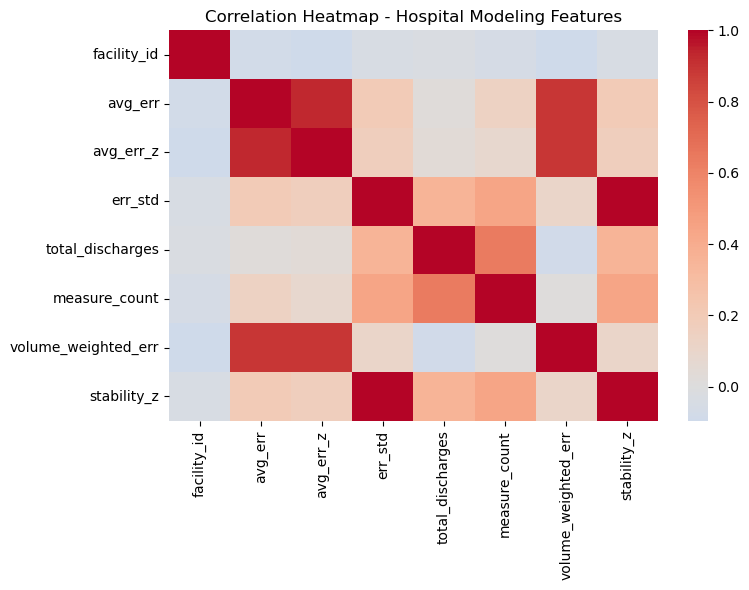

In [19]:
# Correlation heatmap (modeling features) - optional for Slide 2 polish
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = hospital_summary.select_dtypes(include=[np.number]).columns
corr = hospital_summary[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, center=0, cmap="coolwarm")
plt.title("Correlation Heatmap - Hospital Modeling Features")
plt.tight_layout()
plt.savefig(REPORTS_FIG / "hospital_feature_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# ==========================================
# 17. Handle Remaining NaNs
# ==========================================

# If a hospital has only one measure, err_std will be NaN → set to 0
hospital_summary["err_std"] = hospital_summary["err_std"].fillna(0)
hospital_summary["stability_z"] = hospital_summary["stability_z"].fillna(0)

print("Remaining NaNs after handling:")
display(hospital_summary.isna().sum())


Remaining NaNs after handling:


facility_id              0
facility_name            0
state                    0
avg_err                  0
avg_err_z                0
err_std                  0
total_discharges         0
measure_count            0
volume_weighted_err    366
stability_z              0
dtype: int64

In [44]:
# ==========================================
# 18. Save Modeling Dataset
# ==========================================

output_path = DATA_PROCESSED / "cms_hrrp_hospital_modeling_dataset.parquet"

hospital_summary.to_parquet(output_path, index=False)

print(f"Modeling dataset saved to: {output_path}")


Modeling dataset saved to: C:\Users\jsrin\post_discharge_strategy\data\processed\cms_hrrp_hospital_modeling_dataset.parquet
